In [28]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [29]:
iris=sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
iris["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [31]:
iris["species"]=iris["species"].map({"setosa":0,"versicolor":1,"virginica":2})

In [32]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


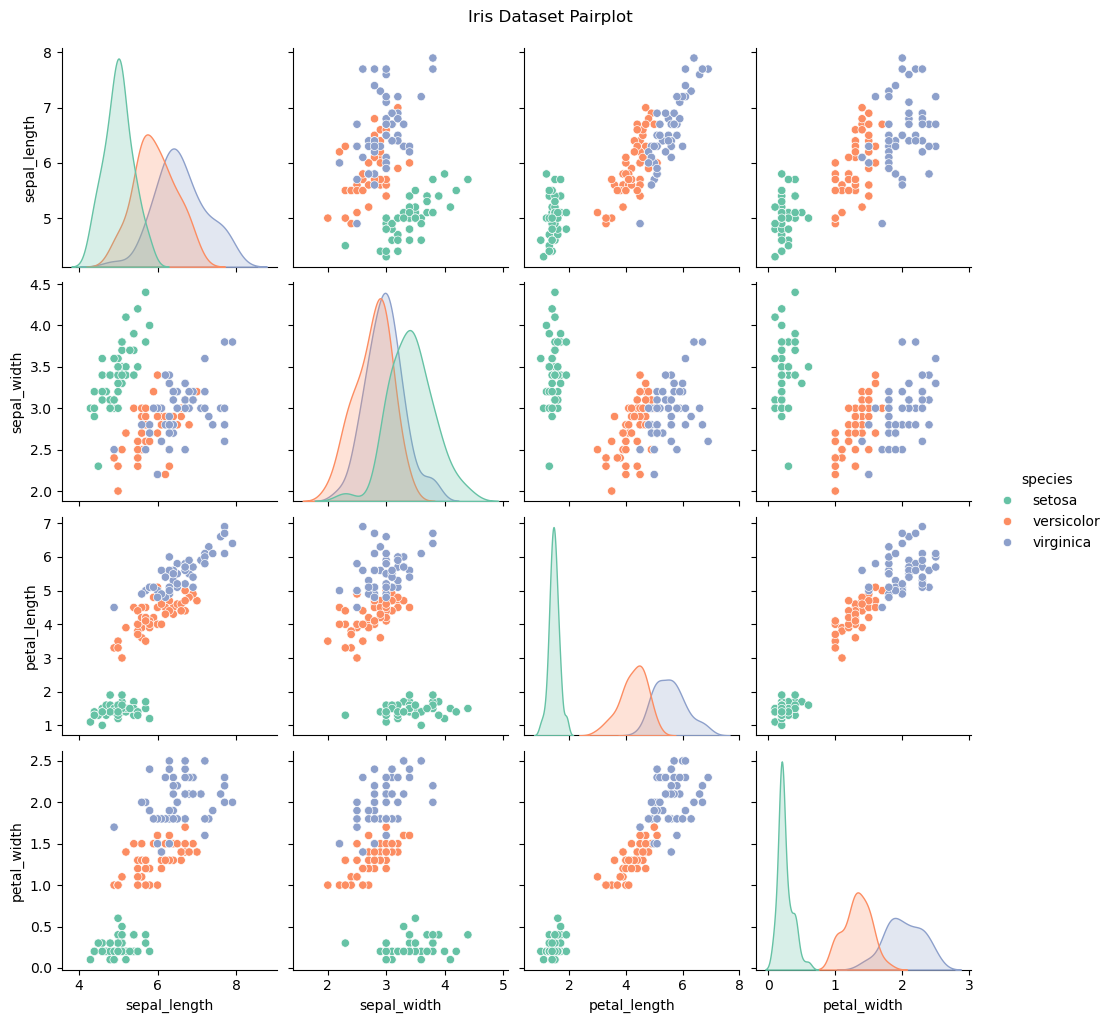

In [46]:
sns.pairplot(iris, hue="species", palette="Set2", diag_kind="kde")
plt.suptitle("Iris Dataset Pairplot", y=1.02)
plt.show()

In [45]:
# LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import seaborn as sns

# Load data
iris = sns.load_dataset("iris")

# Features and target
X = iris.drop(columns="species")
y = iris["species"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred)* 100," % " )
print("Precision:", precision_score(y_test, y_pred , average="macro")* 100," % ")
print("Recall:", recall_score(y_test, y_pred  , average="macro")* 100," % ")

# Optional: full report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 100.0  % 
Precision: 100.0  % 
Recall: 100.0  % 

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [48]:
# Naive Bays Algorithm
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = GaussianNB()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred)* 100," % " )
print("Precision:", precision_score(y_test, y_pred , average="macro")* 100," % ")
print("Recall:", recall_score(y_test, y_pred  , average="macro")* 100," % ")


Accuracy: 100.0  % 
Precision: 100.0  % 
Recall: 100.0  % 


In [54]:
# Knn Algorithm
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = KNeighborsClassifier(n_neighbors=13)
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred)* 100," % " )
print("Precision:", precision_score(y_test, y_pred , average="macro")* 100," % ")
print("Recall:", recall_score(y_test, y_pred  , average="macro")* 100," % ")


Accuracy: 100.0  % 
Precision: 100.0  % 
Recall: 100.0  % 


In [72]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
import seaborn as sns

# Load Iris dataset
iris = sns.load_dataset("iris")
X = iris.drop("species", axis=1)
y = iris["species"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
knn_model = KNeighborsClassifier()

# Hyperparameter grid
param = {"n_neighbors": [3,5,7,9,11]}

# GridSearchCV
classifier = GridSearchCV(
    estimator=knn_model,
    param_grid=param,
    cv=5,
    scoring="accuracy",
    
)

# Fit on scaled data
classifier.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = classifier.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")
print("Precision:", precision_score(y_test, y_pred, average="macro") * 100, "%")
print("Recall:", recall_score(y_test, y_pred, average="macro") * 100, "%")

# GridSearchCV results
res = pd.DataFrame(classifier.cv_results_)

res[['param_n_neighbors', 'mean_test_score', 'rank_test_score']]



Accuracy: 100.0 %
Precision: 100.0 %
Recall: 100.0 %


,param_n_neighbors,mean_test_score,rank_test_score
0,3,0.950000,1
1,5,0.925000,5
2,7,0.941667,3
3,9,0.941667,3
4,11,0.950000,1


In [76]:
# pipeline validation
from sklearn.pipeline import Pipeline

# Load Iris dataset
iris = sns.load_dataset("iris")
X = iris.drop("species", axis=1)
y = iris["species"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
knn_model = KNeighborsClassifier()
pipe = Pipeline([('scaler', StandardScaler()), ('knn_model', KNeighborsClassifier())])
param={"knn__n_neighbors":[3,5,7,9,11]}
clasifier=GridSearchCV(
    knn_model,
    param,
    cv=5,
)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")
print("Precision:", precision_score(y_test, y_pred, average="macro") * 100, "%")
print("Recall:", recall_score(y_test, y_pred, average="macro") * 100, "%")

# GridSearchCV results
res = pd.DataFrame(classifier.cv_results_)

res[['param_n_neighbors', 'mean_test_score', 'rank_test_score']]

Accuracy: 100.0 %
Precision: 100.0 %
Recall: 100.0 %


,param_n_neighbors,mean_test_score,rank_test_score
0,3,0.950000,1
1,5,0.925000,5
2,7,0.941667,3
3,9,0.941667,3
4,11,0.950000,1


In [77]:
y_pred

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)